## Median Filter
In dieser Übungseinheit implementieren Sie einen Medianfilter zur Rauschunterdrückung in Bildern. Der Medianfilter ersetzt jeden Pixelwert durch den Median der Pixelwerte in seiner Nachbarschaft.
Im Genegsatz zu anderen Glättungsfiltern wie einem Box / Mittelwertsfilter, dem Gaussfilter ist der Medianfilter besonders effektiv bei der Entfernung von Salz-und-Pfeffer-Rauschen. Ebenso ist der Medianfilter ein kantenerhaltender Filter, der Kanten im Bild besser bewahrt und diese bei der Filterung weniger verwischt.
Als Nichtlinearer Filter ist der Reechenaufwand für den Medianfilter höher als im Falle einer linearen Filterung.

In [1]:
# package import
import numpy as np
import matplotlib.pyplot as plt
import cv2
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from modules import plotting

Datentyp des Bildes: uint8
Größe des Bildes: (512, 512)


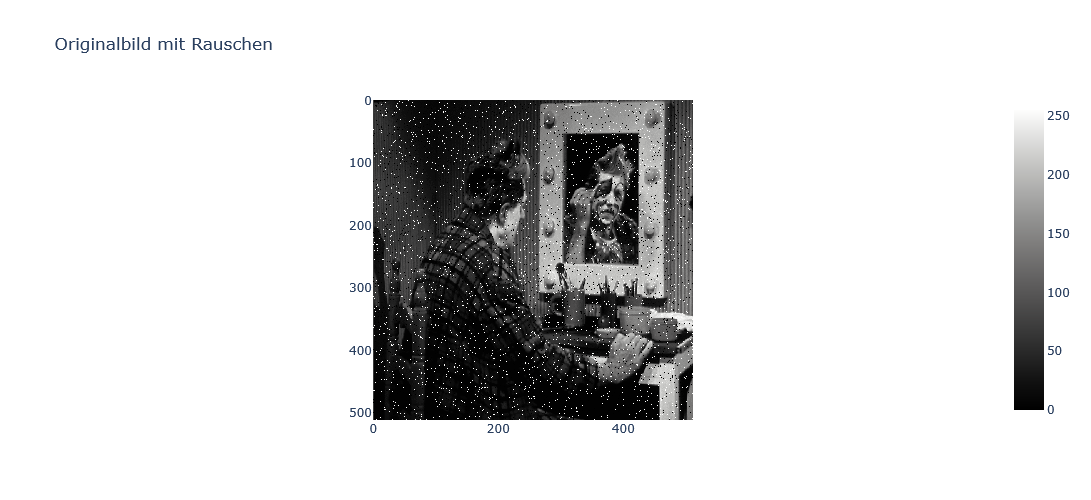

In [2]:
# Bilddatei einladen
image = cv2.imread(r'images/clown_noise.png', cv2.IMREAD_GRAYSCALE)

#Datentyp:
imageDataType = image.dtype  ## ENTER YOUR CODE HERE
#Bildgröße
imageShape =  image.shape  ## ENTER YOUR CODE HERE

# Ausgabe der Daten
print(f'Datentyp des Bildes: {imageDataType}')
print(f'Größe des Bildes: {imageShape}')

# Anzeige des Originalbildes
plotting.displayImagePlotly(image, title='Originalbild mit Rauschen')

### Filterfunktion implementieren
#### Aufgabe
Implementieren Sie die Funktion `median_filter`, die einen Medianfilter auf ein Eingabebild anwendet. Die Funktion soll zwei Parameter akzeptieren: das Eingabebild und die Größe des Filters (z.B. 3 für einen 3x3 Filter). Die Funktion soll das gefilterte Bild zurückgeben.

**Hinweis Padding:** Die Ränder des Bildes müssen nicht speziell behandelt werden (no padding). Sie können die Filterung nur auf die Pixel anwenden, bei denen der Filter vollständig innerhalb des Bildes liegt. Das gefilterte Bild ist dann dementsprechend etwas kleiner als das Eingangsbild.

Bei der Implementierung können Sie folgendermaßen vorgehen:

1) Berechnung der Bildgröße des gefilterten Bildes basierend auf der Filtergröße und der Größe des Eingangsbildes. (Skizzieren Sie dies ggf. auf einem Blatt Papier, um ein besseres Verständnis zu bekommen.)

2) Initialisierung eines leeren Arrays (Wert 0) für das Ergebnis Bild.

3) Iteration über jedes Pixel im Eingangsbild, das vollständig vom Filter abgedeckt wird.
    - Iterieren Sie hier über die Pixel des Ergebnisbildes. Überlegen Sie sich, wie der zugehörige Bildausschnitt im Eingangsbild beschrieben werden kann. (vorher auf einem Blatt Papier skizzieren))
    - Extrahieren Sie den entsprechenden Bildausschnitt aus dem Eingangsbild.

4) Berechnung des Medians der Pixelwerte im extrahierten Bildausschnitt. Verwenden Sie hierfür die NumPy-Funktion `np.median()`.






In [3]:
def median_filter(image, filter_size):
    """Apply median filter to reduce noise in grayscale images.
    
    Args:
        image (numpy.ndarray): Grayscale input image (uint8)
        filter_size (int): Size of the filter kernel (e.g., 3 for 3x3)
        
    Returns:
        numpy.ndarray: Filtered image (same dtype as input, reduced size)
    """

    ####
    ## ENTER YOUR CODE HERE
    ####


    imageSizeX = image.shape[0]
    imageSizeY = image.shape[1]
    # Anwendung des Medianfilterd
    
    # Leeres Filter Bild der richtigen Größe anlegen. 
    image_filtered = np.zeros((imageSizeX- filter_size +1, imageSizeY - filter_size +1))
   
    for i in range(image_filtered.shape[0]):
        for j in range(image_filtered.shape[1]):
             image_ROI = image[i:i + filter_size, j:j + filter_size]
             
             # Median der Werte im Filterberech berechnen
             image_filtered[i, j] = np.median(image_ROI)

    return image_filtered.astype(image.dtype) # Rückgabe des gefilterten Bildes im gleichen Datentyp wie das Eingabebild

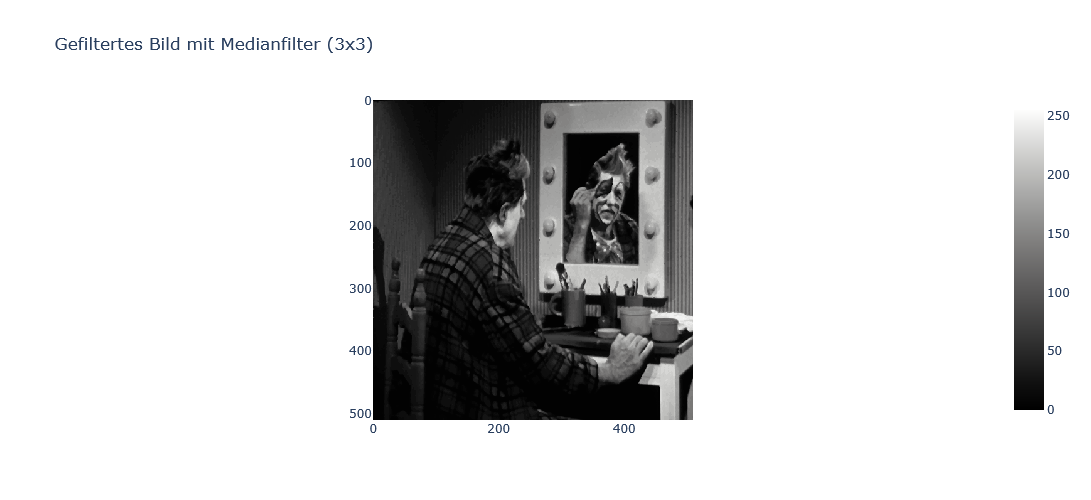

In [4]:
filterSize = 3
image_filtered = median_filter(image, filterSize)

plotting.displayImagePlotly(image_filtered, title= f'Gefiltertes Bild mit Medianfilter ({filterSize}x{filterSize})')
